# Project Exposition and Explanation

Libraries used: polars, numpy, matplotlib, seaborn, pandas, sklearn

GitHub Repo: https://github.com/malakw04/comp333-project \
--> Included in the repo are: instructions on how to run the notebook and the dataset \
Note: Using polars instead of pandas as it is more efficient with large file sizes (polars is multithreaded, pandas is singlethreaded)\

File explanation: the file we chose was a csv file of weather data (max and min temp, precipitation, evaporation, as well as station id, date, longitude, latitude and elevation), spanning from 01/01/1992 to 31/12/2021.

The following occurs in a seperate test notebook, as we were unsure of how to trim down on the amount of data used (as >8gb is very large to handle, and we wanted to work with a more useful subset of the data)

Started with initial file of ~8gb (weather.csv) \
Read and displayed file \
Filter data by the following metrics:
1.  2010 and newer (2010 - 2021)
    1. Ultimately the idea failed as the file size was still quite large (>4gb)
    2. We ran the quantDDA() function and decided to abandon the idea
2. Latitude >=-80
    1. Failed because the dataset was less than 1gb (failed requirements for the project)
3. Latitude >=-85
    1. Was going well until we ran quantDDA() and were shown that TMAX and TMIN had ~45% non-null values (meaning we couldn't use much of the data for training)
    2. Ultimately we abandoned the latitude idea

## Started from scratch -- this is the new working file

We decided to drop the EVAP column as there was ~1% of non-null data (we couldn't do anything with that even if we tried) \
We came up with the idea to create a column called 'non_null_percentage', which found the percent full of TMAX, TMIN and PRCP (we excluded the ID, DATE, Longitude, Latitude, and Elevation as all of these columns were 100% full and thus unnessecary towards the calculations)\
Then, we grouped each station and got the 'non_null_percentage' average across each station, and kept the stations with 98% or more non_null_percentage. \
This is the dataset we decided to use for our project.

#### Supervised/Unsupervised Questions:
**Supervised**: Can we predict if it will rain tomorrow? \
**Unsupervised**: Can we identify weather patterns that lead to distinct meteorological events?

# Phase 1

### Division of Labour:

Sean: Code Blocks [1] - [16] \
Malak: Clode Blocks [17] - [25] \
Both worked on the markdown, setting up the GitHub repo and equal time was spent on all tasks.



In [1]:
import polars as pl

file_name = "/Users/sean/Documents/comp333_project/weather_data_us.csv"

df = pl.read_csv(file_name)

In [2]:
columns_to_check = ['TMAX', 'TMIN', 'PRCP']
num_columns = len(columns_to_check)

df_with_percentage = df.with_columns(
    (
        pl.sum_horizontal(pl.col(c).is_not_null() for c in columns_to_check).cast(pl.Float64) / num_columns
    ).alias('non_null_percentage')
)

In [3]:
df_with_percentage


ID,DATE,TMAX,TMIN,EVAP,PRCP,Latitude,Longitude,Elevation,non_null_percentage
str,str,i64,i64,str,i64,f64,f64,f64,f64
"""USS0012M13S""","""3/26/1997""",null,null,null,0,37.66,-112.74,2920.0,0.333333
"""US1OKCV0021""","""4/18/2007""",null,null,null,241,35.1715,-97.4262,355.1,0.333333
"""USC00355174""","""10/7/1999""",null,null,null,null,42.0078,-121.3186,1410.3,0.0
"""US1MDHW0012""","""10/14/2015""",null,null,null,0,39.3387,-76.9468,166.1,0.333333
"""US1TXHRS014""","""10/4/2021""",null,null,null,0,32.7061,-94.1683,53.6,0.333333
…,…,…,…,…,…,…,…,…,…
"""US1MNMW0008""","""11/14/2021""",null,null,null,5,43.6719,-93.0228,365.2,0.333333
"""US1KSJA0001""","""8/27/2014""",null,null,null,5,39.3032,-95.8141,365.8,0.333333
"""US1NEDG0029""","""6/15/2019""",null,null,null,5,41.214,-96.1908,366.1,0.333333


In [4]:
result = df_with_percentage.group_by("ID").agg(
    pl.col("non_null_percentage").mean()
)

result


ID,non_null_percentage
str,f64
"""US1TNPM0005""",0.328895
"""US1NYST0016""",0.325902
"""US1NDBH0045""",0.312715
"""USC00309303""",0.332122
"""US1WYFM0055""",0.331197
…,…
"""US1WYSL0002""",0.327029
"""US1NMDA0367""",0.32958
"""US1COLR0110""",0.332393


In [5]:
result = result.sort("non_null_percentage", descending=True)
result

ID,non_null_percentage
str,f64
"""USC00178792""",1.0
"""USW00014737""",1.0
"""USW00013748""",1.0
"""USC00364417""",1.0
"""USC00300961""",1.0
…,…
"""USC00513770""",0.0
"""US1ALCY0002""",0.0
"""US1MIHG0014""",0.0


This is the basis for how much of our data we kept. 

We chose to keep every station that had 98% or more non_null_percentage as we have a large amount of data to work with without having the hurdle of deciding how to handle the null values. 

We tested with non_null_percentages of >50%, >75%, >90% and >95% before settling on >=98%.

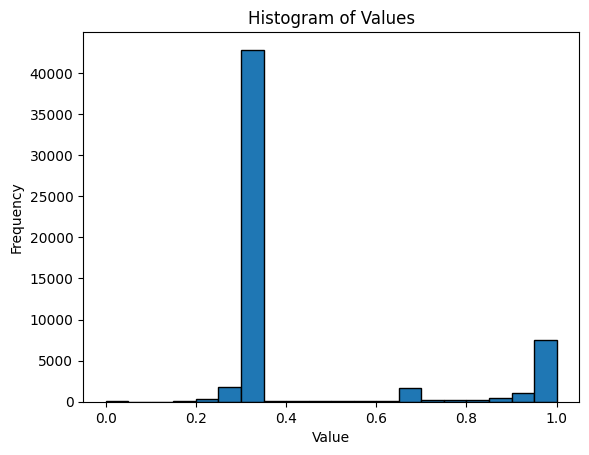

In [6]:
import matplotlib.pyplot as plt

plt.hist(result["non_null_percentage"], bins=20, edgecolor='black')
plt.title("Histogram of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [7]:
result_greater_than_98 = result.filter(pl.col("non_null_percentage") >= 0.98)

result_greater_than_98

In [8]:
values_list = result_greater_than_98["ID"].to_list()


We then created a filtered_df which includes all of the stations from the list of stations to keep. 

In [9]:
filtered_df = df.filter(pl.col("ID").is_in(values_list))


Slight feature engineering, we dropped the EVAP column, and changed the TMAX and TMIN columns from tenths of a degree celcius to a degree celcius.

We then wrote it to a csv file to have the new dataset

In [10]:

filtered_df = filtered_df.drop("EVAP")

filtered_df = filtered_df.with_columns([
    (pl.col("TMAX") / 10).alias("TMAX"),
    (pl.col("TMIN") / 10).alias("TMIN")
])

filtered_df

ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation
str,str,f64,f64,i64,f64,f64,f64
"""USC00201675""","""9/26/2012""",20.0,10.0,0,41.9622,-84.9925,299.9
"""USC00206510""","""8/2/2018""",26.7,15.6,28,45.3614,-84.9511,228.0
"""USC00352440""","""6/21/2012""",31.1,6.1,null,45.4539,-121.1303,405.4
"""USW00013866""","""12/1/2002""",0.6,-4.4,3,38.3794,-81.5911,278.0
"""USW00054780""","""10/17/2001""",17.2,10.0,0,41.0731,-71.9236,2.1
…,…,…,…,…,…,…,…
"""USW00023904""","""4/10/2018""",14.7,0.7,4,35.82,-91.7811,138.7
"""USW00003086""","""5/21/2012""",27.5,12.1,4,37.3814,-102.7194,1389.0
"""USW00063850""","""7/30/2012""",33.2,19.8,4,33.7836,-83.3897,225.9


In [11]:
filtered_df.write_csv("filtered_df.csv")

import os

r_size = os.path.getsize(file_name)
print(f"File size before filtering: {r_size} bytes")

f_size = os.path.getsize("filtered_df.csv")
print(f"File size after filtering: {f_size} bytes")

File size before filtering: 8367753313 bytes
File size after filtering: 2901891131 bytes


quantDDA() from lab 2 was used, needed to convert the code from using pandas to polars, otherwise no change.

Added a column of non missing percent at the end (count /total_obs) to see how many null values we had as a percentage (everything is 99% or higher)

We will detect numeric outliers using the IQR rule and percentile-based thresholds, then inspect whether they reflect true meteorological extremes or data quality issues. Because weather naturally contains real extreme events, outliers will not be automatically removed; instead, we will flag suspicious values and only cap or exclude physically implausible observations.

In [12]:
def detect_outliers_iqr(df, col):
    q1 = df.select(pl.col(col).quantile(0.25)).item()
    q3 = df.select(pl.col(col).quantile(0.75)).item()
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return df.filter((pl.col(col) < lower) | (pl.col(col) > upper))

for col in ["TMAX", "TMIN", "PRCP", "Elevation"]:
    outliers = detect_outliers_iqr(filtered_df, col)
    print(col, outliers.height)

TMAX 78052
TMIN 269824
PRCP 8369765
Elevation 1320884


If duplicate station-date records exist, we will inspect whether they are true duplicates or conflicting observations. Exact duplicates will be removed; conflicting duplicates will be resolved by keeping the most complete row or aggregating if appropriate.

In [13]:
duplicate_count = filtered_df.height - filtered_df.unique().height
print("Exact duplicate rows:", duplicate_count)

station_date_duplicates = (
    filtered_df.group_by(["ID", "DATE"])
    .len()
    .filter(pl.col("len") > 1)
)
print("Duplicate station-date pairs:", station_date_duplicates.height)

Exact duplicate rows: 0
Duplicate station-date pairs: 0


In [14]:
import polars as pl
import polars.selectors as cs

def quantDDA(df_input: pl.DataFrame, sample_size: int = 100_000) -> pl.DataFrame:
    
    # Systematic sample for large datasets
    if len(df_input) > sample_size:
        step = len(df_input) // sample_size
        df_input = df_input.gather_every(step)
        print(f"Sampled every {step}th row → {len(df_input):,} rows used for stats")

    numeric_cols = df_input.select(cs.numeric()).columns
    total_obs = len(df_input)

    stats = [
        pl.lit(total_obs).alias("Total_Obs"),
        cs.all().count().name.prefix("Entries_"),
        cs.all().n_unique().name.prefix("Unique_"),
        cs.all().null_count().name.prefix("Null_"),
    ]

    for col in numeric_cols:
        series = df_input.get_column(col)
        q1 = series.quantile(0.25)
        q2 = series.quantile(0.5)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        p01, p99 = series.quantile(0.01), series.quantile(0.99)
        stats.extend([
            ((pl.col(col) < (q1 - 1.5 * iqr)) | (pl.col(col) > (q3 + 1.5 * iqr))).sum().alias(f"Outliers_{col}"),
            ((pl.col(col) < p01) | (pl.col(col) > p99)).sum().alias(f"Extreme_{col}"),
            pl.col(col).mode().first().alias(f"Mode_{col}"),
            pl.col(col).mean().round(2).alias(f"Mean_{col}"),
            pl.col(col).std().round(2).alias(f"StdDev_{col}"),
            pl.col(col).max().alias(f"Max_{col}"),
            pl.col(col).min().alias(f"Min_{col}"),
            pl.lit(q1).alias(f"Q1_{col}"),
            pl.lit(q2).alias(f"Q2_{col}"),
            pl.lit(q3).alias(f"Q3_{col}"),
            pl.col(col).skew().round(4).alias(f"Skew_{col}"),
            pl.col(col).kurtosis().round(4).alias(f"Kurt_{col}"),
        ])

    stats.append(
        ((cs.all().count() / total_obs) * 100).round(2).name.prefix("NonMissingPct_")
    )

    res_wide = df_input.select(stats)
    res_long = res_wide.unpivot().with_columns(
        pl.col("variable").str.splitn("_", 2).struct.field("field_0").alias("Stat"),
        pl.col("variable").str.splitn("_", 2).struct.field("field_1").alias("Feature")
    )

    final_df = res_long.pivot(index="Feature", on="Stat", values="value")
    final_df = final_df.fill_null("-")

    if "NonMissingPct" in final_df.columns:
        cols = [c for c in final_df.columns if c != "NonMissingPct"] + ["NonMissingPct"]
        final_df = final_df.select(cols)

    return final_df

In [15]:
quantDDA(filtered_df)

Sampled every 424th row → 100,195 rows used for stats


Feature,Total,Entries,Unique,Null,Outliers,Extreme,Mode,Mean,StdDev,Max,Min,Q1,Q2,Q3,Skew,Kurt,NonMissingPct
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Obs""",100195.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ID""",null,100195.0,5354.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""DATE""",null,100195.0,10592.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""TMAX""",null,99551.0,635.0,644.0,166.0,1879.0,28.3,17.17,11.84,50.1,-51.3,8.3,18.3,26.7,-0.3969,-0.4122,99.36
"""TMIN""",null,99496.0,617.0,699.0,677.0,1749.0,0.0,4.6,10.77,95.7,-63.7,-2.3,4.9,12.8,-0.3393,0.0174,99.3
"""PRCP""",null,99493.0,493.0,702.0,19740.0,982.0,0.0,24.44,76.31,2471.0,0.0,0.0,0.0,8.0,6.6335,76.3181,99.3
"""Latitude""",null,100195.0,4991.0,0.0,2394.0,1988.0,45.19,40.23,6.06,71.2869,19.2706,36.1839,40.45,44.0217,0.6388,2.7006,100.0
"""Longitude""",null,100195.0,5164.0,0.0,1060.0,1992.0,-110.68,-99.12,16.72,174.1,-170.2228,-111.42,-97.6003,-85.8958,-0.4177,2.539,100.0
"""Elevation""",null,100195.0,2710.0,0.0,3194.0,1887.0,3.0,744.71,820.27,3541.8,-999.9,166.1,350.5,1204.0,1.3137,0.7504,100.0


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pandas as pd
import numpy as np


def vizDDA(df_input: pl.DataFrame, sample_size: int = 50_000):

    if len(df_input) > sample_size:
        step = len(df_input) // sample_size
        df_input = df_input.gather_every(step)
        print(f"Sampled every {step}th row → {len(df_input):,} rows used for viz")
        
    df_input = df_input.drop("ID")


    
    headers = df_input.columns
    n_obs = len(df_input)

    stat_data = {
        "#Observations": [n_obs] * len(headers),
        "#Entries": [df_input[col].drop_nulls().len() for col in headers],
        "#Unique": [df_input[col].n_unique() for col in headers],
    }

    stat_df = pd.DataFrame(stat_data, index=headers)
    stat_df["Is_Unique"] = ~(
        (stat_df["#Observations"] == stat_df["#Entries"]) &
        (stat_df["#Observations"] == stat_df["#Unique"])
    )

    cols_to_plot = stat_df[stat_df["Is_Unique"]].index.tolist()
    df_filtered = df_input.select(cols_to_plot)

    #Convert once outside the loop
    df_pd = df_filtered.to_pandas()

    cols = df_filtered.columns
    n = len(cols)

    #pre-compute n_unique and dtype for all columns once
    n_unique = {col: df_filtered[col].n_unique() for col in cols}

    def is_numeric(col):
        return df_filtered[col].dtype in (
            pl.Int8, pl.Int16, pl.Int32, pl.Int64,
            pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
            pl.Float32, pl.Float64
        )

    is_num = {col: is_numeric(col) for col in cols}

    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    if n == 1:
        axes = np.array([[axes]])

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            col_x = cols[j]
            col_y = cols[i]

            is_x_num = is_num[col_x]
            is_y_num = is_num[col_y]
            is_x_messy = n_unique[col_x] > 20 and not is_x_num
            is_y_messy = n_unique[col_y] > 20 and not is_y_num

            if i == j:
                if is_x_num:
                    sns.histplot(data=df_pd[col_x], ax=ax, kde=True)
                else:
                    if is_x_messy:
                        ax.text(0.5, 0.5,
                                f"Too many unique \nvalues in {col_x}: ({n_unique[col_x]})",
                                ha="center", va="center")
                    else:
                        sns.countplot(data=df_pd, x=col_x, ax=ax)
                        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
                ax.set_title(f"Dist of {col_x}")

            else:
                if is_x_messy and is_y_messy:
                    if is_x_num and is_y_num:
                        #sample large datasets for scatterplots
                        plot_data = df_pd[[col_x, col_y]].dropna()
                        if len(plot_data) > 5000:
                            plot_data = plot_data.sample(5000)
                        sns.scatterplot(data=plot_data, x=col_x, y=col_y, ax=ax)
                    else:
                        ax.text(0.5, 0.5,
                                f"High Cardinality\n{col_x}: {n_unique[col_x]} unique\n{col_y}: {n_unique[col_y]} unique",
                                ha="center", va="center", fontsize=9)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)

                elif is_x_num and is_y_num:
                    plot_data = df_pd[[col_x, col_y]].dropna()
                    if len(plot_data) > 5000:
                        plot_data = plot_data.sample(5000)
                    sns.scatterplot(data=plot_data, x=col_x, y=col_y, ax=ax)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)

                elif is_x_num != is_y_num:
                    df_temp = df_pd[[col_x, col_y]].dropna()
                    if not is_x_num and is_x_messy:
                        top_cats = df_temp[col_x].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_x].isin(top_cats)]
                    if not is_y_num and is_y_messy:
                        top_cats = df_temp[col_y].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_y].isin(top_cats)]
                    sns.boxplot(data=df_temp, x=col_x, y=col_y, ax=ax)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)
                    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

                else:
                    df_temp = df_pd[[col_x, col_y]].dropna()
                    if is_x_messy:
                        top_x = df_temp[col_x].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_x].isin(top_x)]
                    if is_y_messy:
                        top_y = df_temp[col_y].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_y].isin(top_y)]
                    ct = pd.crosstab(df_temp[col_y], df_temp[col_x])
                    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)
                    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)
                    plt.setp(ax.yaxis.get_majorticklabels(), fontsize=7)

    plt.tight_layout()
    plt.show()

    #missing values heatmap
    fig, ax = plt.subplots(figsize=(14, max(6, len(df_input.columns) * 0.4)))
    sns.heatmap(df_pd.isnull(), cbar=True, cmap='viridis', yticklabels=False, ax=ax)
    ax.set_title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, pad=20)
    ax.set_xlabel('Columns', fontsize=12)
    ax.set_ylabel('Observations', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

Sampled every 849th row → 50,039 rows used for viz


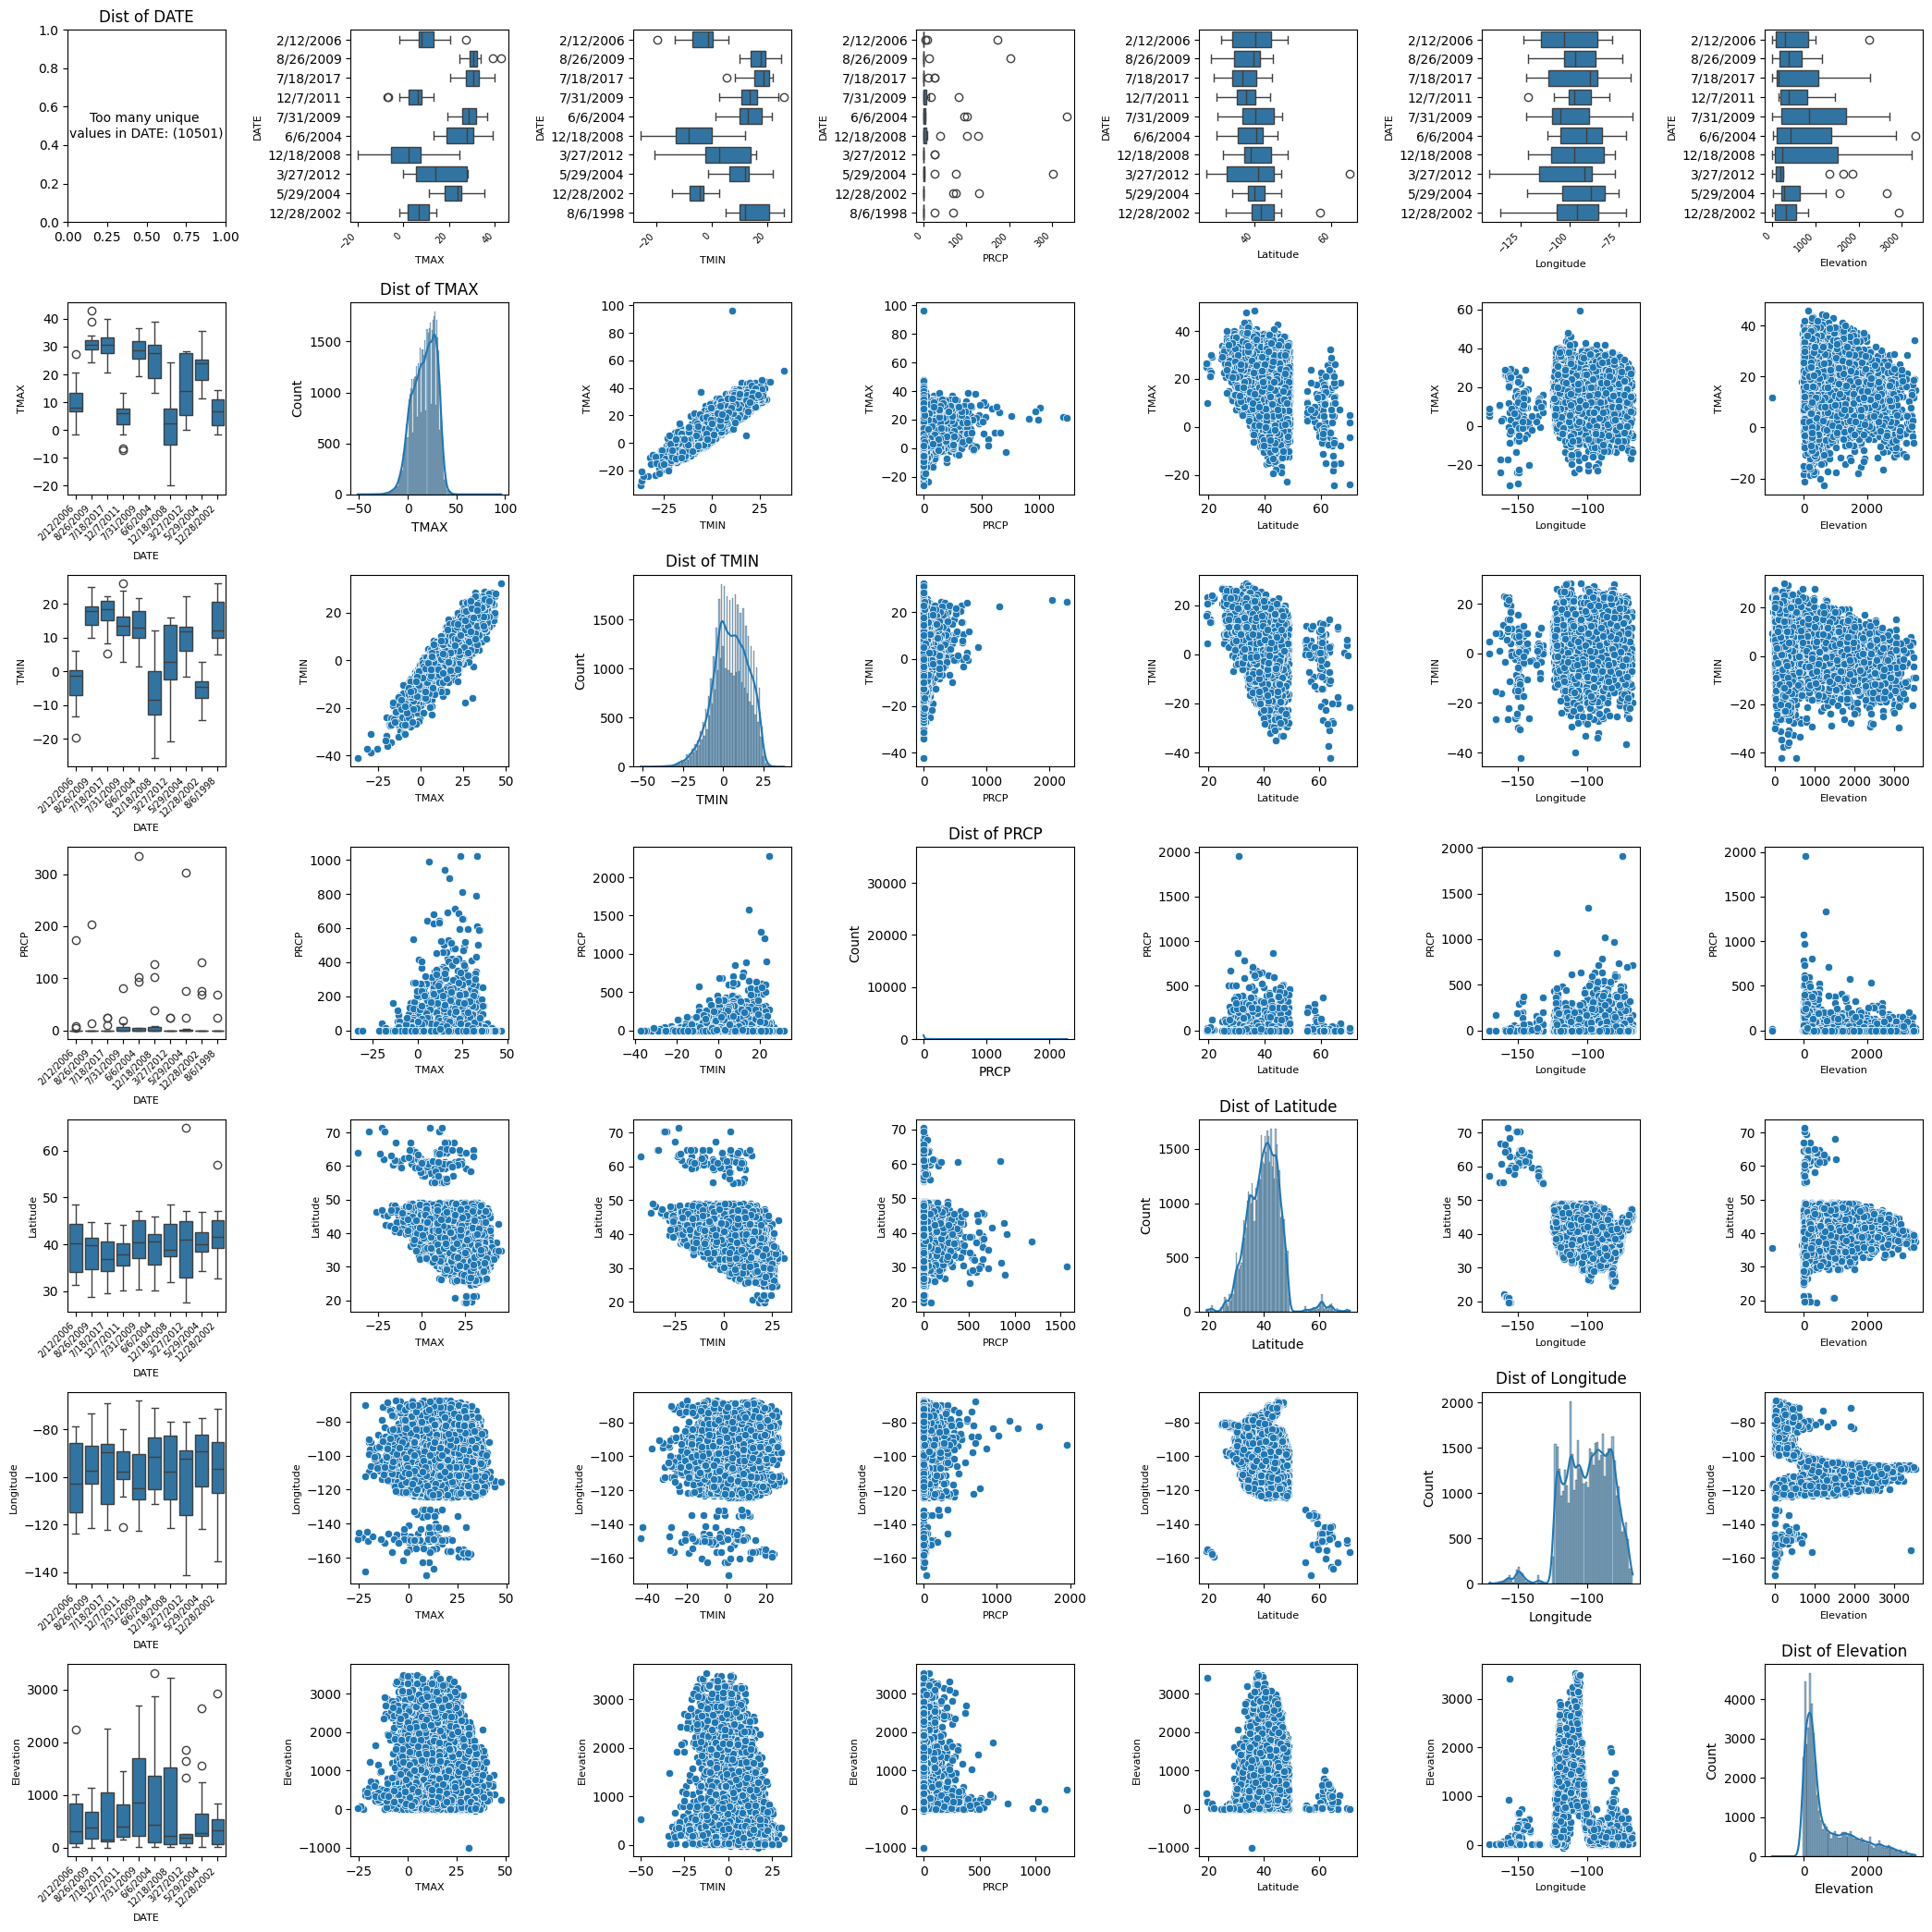

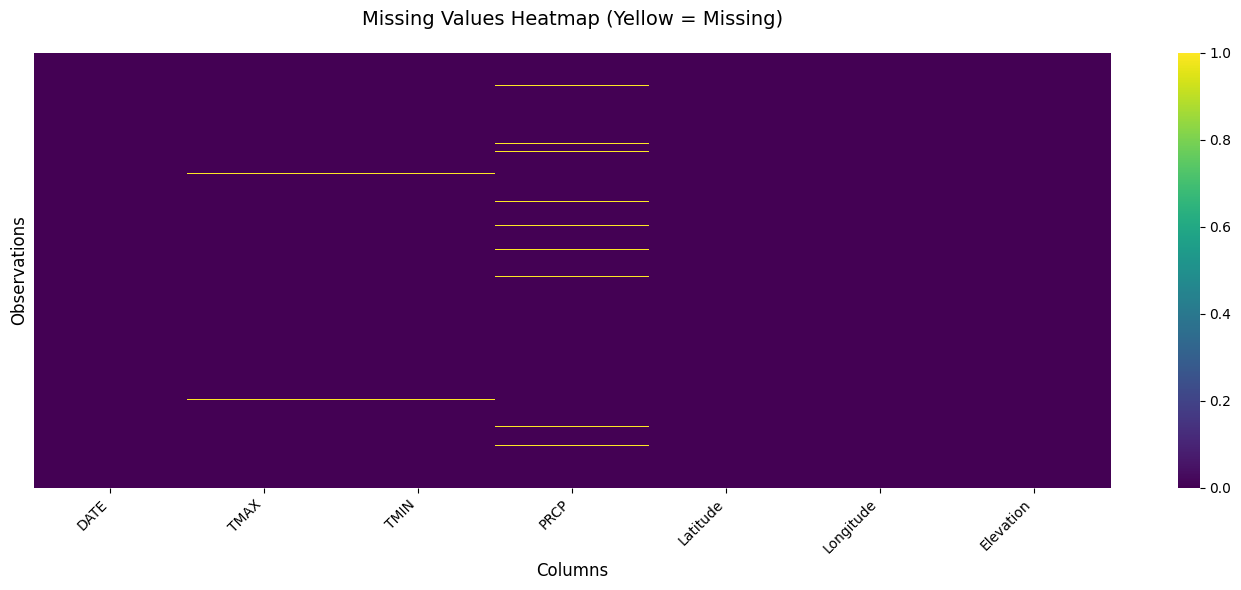

In [17]:
vizDDA(filtered_df)

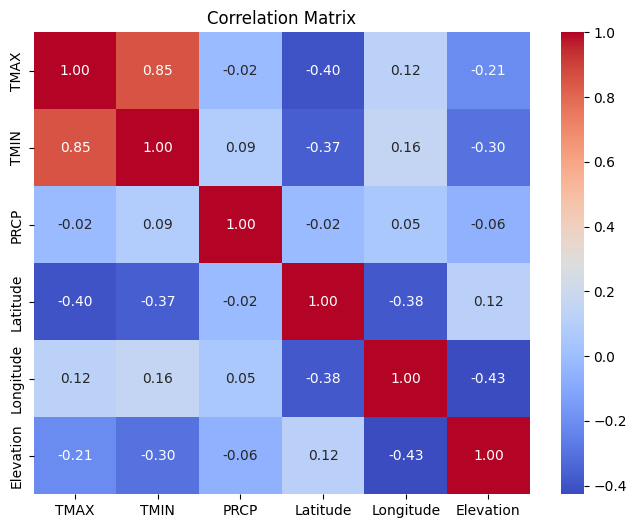

In [18]:
corr_df = (
    filtered_df
    .select(["TMAX", "TMIN", "PRCP", "Latitude", "Longitude", "Elevation"])
    .to_pandas()
    .corr(numeric_only=True)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## EDA Summary 

TMAX and TMIN show a strong positive linear relationship. This suggests temperature patterns are internally consistent across observations. The low missingness after filtering means these are safe core predictors.

PRCP is highly right-skewed, with many zero or low-precipitation days and a small number of extreme rainfall values. This indicates the presence of rare but intense precipitation events, so we will be using robust statistics for interpretation.

Latitude and Longitude display clear clustering patterns, reflecting spatial grouping of weather stations. 

Elevation is also strongly right-skewed, with most stations at low altitude and a smaller number of stations extending into much higher elevations. This is also supported by the positive skewness reported in the summary statistics.

The missing values heatmap shows that the dataset is nearly complete, with only a small number of scattered missing entries (primarily in PRCP and TMIN).

### Baseline Model

To answer our supervised question, *Can we predict whether it will rain or not?*, we decided to use a Decision Tree as our baseline model for phase 1 for the following reasons:
1. Highly interpretable because it provides a rule-based structure that shows us how features are split to make predictions.
2. Does not assume linearity, homoscedasticity, and feature independence.
3. Handles mixed data types.
4. Captures nonlinear relationships. This was crucial for us since our dataset deals with weather which exhibits nonlinear patterns.



In [19]:
import pandas as pd
import numpy as np

In [20]:
#only parse if DATE is still a String type
if filtered_df["DATE"].dtype == pl.Utf8 or filtered_df["DATE"].dtype == pl.String:
    filtered_df = filtered_df.with_columns(
        pl.col("DATE").str.strptime(pl.Date, format="%m/%d/%Y").alias("DATE")
    )

#safe to sort now either way
filtered_df = filtered_df.sort(["ID", "DATE"])

We define a rainy day as PRCP > 0. We first create RainToday, then create the target RainTomorrow by shifting this indicator by one day forward within each weather station. The station-wise shift is important because it prevents records from different stations from being mixed together. The final target is that for each station and date t, RainTomorrow = 1 if precipitation on date t+1 is greater than zero, and 0 otherwise.

In [21]:
#RainTomorrow: tomorrow’s rain label (shifted within each station)
#.over("ID") prevents mixing stations
filtered_df = filtered_df.with_columns(
    (pl.col("PRCP") > 0).cast(pl.Int8).alias("RainToday")
)

filtered_df = filtered_df.with_columns(
    pl.col("RainToday").shift(-1).over("ID").alias("RainTomorrow")
).drop_nulls(subset=["RainTomorrow"])

In [22]:
model_df = filtered_df.select(["DATE", "TMAX", "TMIN", "PRCP", "RainTomorrow"])

We sorted our dataset chronologically and split it as follows:
1. The earliest 70% of observations were used to train the model.
2. The next 15% were used for validation and hyperparameter tuning.
3. The most recent 15% were reserved as a completely unseen test set.

In [23]:
#time-based split
pdf = model_df.to_pandas()
pdf["DATE"] = pd.to_datetime(pdf["DATE"])
pdf = pdf.sort_values("DATE")

train_end = pdf["DATE"].quantile(0.70)
val_end   = pdf["DATE"].quantile(0.85)

train_df = pdf[pdf["DATE"] <= train_end]
val_df   = pdf[(pdf["DATE"] > train_end) & (pdf["DATE"] <= val_end)]
test_df  = pdf[pdf["DATE"] > val_end]

X_train = train_df.drop(columns=["RainTomorrow", "DATE"])
y_train = train_df["RainTomorrow"].astype(int)

X_val = val_df.drop(columns=["RainTomorrow", "DATE"])
y_val = val_df["RainTomorrow"].astype(int)

X_test = test_df.drop(columns=["RainTomorrow", "DATE"])
y_test = test_df["RainTomorrow"].astype(int)

print("Train dates:", train_df["DATE"].min(), "->", train_df["DATE"].max())
print("Val dates:  ", val_df["DATE"].min(), "->", val_df["DATE"].max())
print("Test dates: ", test_df["DATE"].min(), "->", test_df["DATE"].max())

print("\nClass balance (train):")
print(y_train.value_counts(normalize=True))

Train dates: 1992-01-01 00:00:00 -> 2013-06-28 00:00:00
Val dates:   2013-06-29 00:00:00 -> 2017-08-29 00:00:00
Test dates:  2017-08-30 00:00:00 -> 2021-12-30 00:00:00

Class balance (train):
RainTomorrow
0    0.708925
1    0.291075
Name: proportion, dtype: float64


In [24]:
#training 
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,           # because very deep trees can overfit
    min_samples_leaf=50,   # forces each terminal leaf to contain at least 50 observations
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [25]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)
#test
train_pred = tree.predict(X_train)
train_prob = tree.predict_proba(X_train)[:, 1]

print("TRAIN Accuracy:", accuracy_score(y_train, train_pred))
print("TRAIN AUC:", roc_auc_score(y_train, train_prob))
print("TRAIN Confusion Matrix:\n", confusion_matrix(y_train, train_pred))
print("\nTRAIN Classification Report:\n", classification_report(y_train, train_pred))

#validation
val_pred = tree.predict(X_val)
val_prob = tree.predict_proba(X_val)[:, 1]

print("VAL Accuracy:", accuracy_score(y_val, val_pred))
print("VAL AUC:", roc_auc_score(y_val, val_prob))
print("VAL Confusion Matrix:\n", confusion_matrix(y_val, val_pred))
print("\nVAL Classification Report:\n", classification_report(y_val, val_pred))

TRAIN Accuracy: 0.7290284122382004
TRAIN AUC: 0.6895272821629281
TRAIN Confusion Matrix:
 [[19522544  1419240]
 [ 6585313  2013096]]

TRAIN Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.93      0.83  20941784
           1       0.59      0.23      0.33   8598409

    accuracy                           0.73  29540193
   macro avg       0.67      0.58      0.58  29540193
weighted avg       0.70      0.73      0.69  29540193

VAL Accuracy: 0.7229979538804527
VAL AUC: 0.688937277334255
VAL Confusion Matrix:
 [[4126569  311945]
 [1440945  448617]]

VAL Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.93      0.82   4438514
           1       0.59      0.24      0.34   1889562

    accuracy                           0.72   6328076
   macro avg       0.67      0.58      0.58   6328076
weighted avg       0.70      0.72      0.68   6328076



In [26]:
#test
test_pred = tree.predict(X_test)
test_prob = tree.predict_proba(X_test)[:, 1]

print("TEST Accuracy:", accuracy_score(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_prob))
print("TEST Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("\nTEST Classification Report:\n", classification_report(y_test, test_pred))

TEST Accuracy: 0.7241469107889942
TEST AUC: 0.6911037198432569
TEST Confusion Matrix:
 [[4128032  319576]
 [1426136  454668]]

TEST Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.93      0.83   4447608
           1       0.59      0.24      0.34   1880804

    accuracy                           0.72   6328412
   macro avg       0.67      0.58      0.58   6328412
weighted avg       0.70      0.72      0.68   6328412



#### Test Performance

The model indicates moderate predictive ability above random chance. However, accuracy is influenced by class imbalance, as non-rain days (Class 0) dominate the dataset.

From the confusion matrix, , the model performs very well at predicting no rain (recall = 0.93), but struggles significantly with rain detection (recall = 0.24). This means the model misses a large proportion of actual rainy days.

Overall, the model is strong at predicting dry weather but struggles to correctly detect rain events. While we are accepting this as a baseline, improvement is needed to increase recall for rainy days and reduce bias toward the majority class.

In [27]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
2,PRCP,0.883078
0,TMAX,0.072120
1,TMIN,0.044802


# Phase 2

## Responding to Comments Left on Phase 1

**Data Retrieval**
- As mentioned previosuly, we have used a dataset pulled from kaggle (linked in the readme of the GitHub repo provided), and needed to filter through and reduce the size to fit the requirements of our project. We did not required an programmatic retrieval in terms of scraping, API or SQL database, as we downloaded the dataset from kaggle and it was approved by the professor.
- We also computed the raw and filtered sizes of the dataset to verify that the dataset met our projects requirements.

**Unsupervised Question**
- As mentionned in the introductory markdown paragraph above, the unsupervised question is as follows: Can we identify weather patterns that lead to distinct meteorological events?

**Baseline Model**
- We selected TMAX, TMIN, and PRCP because they are direct meteorological variables most closely tied to short-term rainfall behavior. For the Phase 1 baseline, we excluded latitude, longitude, and elevation to keep the model simple and interpretable, and because our initial aim was to establish a weather-only baseline before introducing geographic information. In Phase 2, we will test whether adding geographic features improves predictive performance.
- We added a small markdown explaining how RainTomorrow was built before its corresponding code.
- We tested multiple combinations of max_depth and min_samples_leaf and selected the model with the best validation AUC while also favoring simpler trees to reduce overfitting.
- We added code to compare train, validation, and test and a markdown to interpret it.



To address the unsupervised learning requirement, we applied Principal Component Analysis (PCA) to reduce the dimensionality of the engineered weather features while preserving most of the variance in the data. We then used KMeans clustering on the reduced feature space and selected the optimal number of clusters using both the Elbow Method and Silhouette Score.

This approach is appropriate because the dataset contains many continuous and correlated meteorological variables, which can make clustering in the original feature space noisy and difficult to interpret. PCA helps compress the information into a smaller number of informative components, while KMeans provides an efficient and interpretable way to identify distinct weather patterns.

## Advanced Models

To improve upon the baseline Decision Tree, we implemented advanced ensemble models including Random Forest and XGBoost.

Given the imbalanced nature of the dataset, evaluation focused primarily on F1-score, Recall, and AUC, as these metrics better capture performance on the minority class compared to accuracy.

The Decision Tree achieved relatively high accuracy (approx. 0.72), but its recall was very low (approx. 0.24), indicating poor ability to detect rain events. This resulted in a weak F1-score (approx. 0.34), making it unsuitable despite its accuracy.

In contrast, ensemble models significantly improved performance:
- XGBoost achieved a recall of approx. 0.68 and an F1-score of approx. 0.55
- Random Forest achieved a recall of approx. 0.59 and an F1-score of approx. 0.53

Additionally, both models achieved higher AUC values (~approx. 0.72 to 0.74), indicating better overall classification ability.

The performance of the advanced models was further analyzed using ROC curves and confusion matrices to better understand their classification behavior beyond summary metrics.

The ROC curves show that both Random Forest and XGBoost achieve AUC values of approximately 0.70, indicating moderate ability to distinguish between rain and no-rain events. While both models outperform the baseline Decision Tree in terms of discrimination, the separation between classes is still limited at this stage.

The confusion matrices provide additional insight into model performance. The Decision Tree produces a high number of false negatives, meaning that many actual rain events are incorrectly classified as no rain. This explains its very low recall, despite having relatively high accuracy.

In contrast, Random Forest and XGBoost significantly reduce false negatives, leading to higher recall values. However, this improvement comes with a slight increase in false positives, indicating a trade-off between sensitivity and precision.

These results show that ensemble methods are far more effective at identifying the minority class, making them better suited for this problem.

### Updated Division of Labour

Sean: Cells [33] - [44]
Malak: Cells [28] - [33], [45]-[55]
There were several moments where we collaborated and helped each other out, this is just a rough division based on delegated tasks early on in Phase 2.

In [28]:
train_sample = train_df.sample(n=500_000, random_state=42)
X_train_s = train_sample.drop(columns=["RainTomorrow", "DATE"])
y_train_s = train_sample["RainTomorrow"].astype(int)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100, #changed from 200
    max_depth=8, #changed from 12
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_s, y_train_s)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [30]:
from xgboost import XGBClassifier

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train_s, y_train_s)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate(model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "AUC": roc_auc_score(y, prob),
    }

In [32]:
results = pd.DataFrame({
    "Decision Tree": evaluate(tree, X_test, y_test),
    "Random Forest": evaluate(rf_model, X_test, y_test),
    "XGBoost": evaluate(xgb_model, X_test, y_test)
}).T
print(results.sort_values("AUC", ascending=False))

# Confusion matrices separately
for name, model in [("Decision Tree", tree), ("Random Forest", rf_model), ("XGBoost", xgb_model)]:
    pred = model.predict(X_test)
    print(f"\n{name} Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

               Accuracy  Precision    Recall        F1       AUC
Random Forest  0.691240   0.483048  0.554187  0.516178  0.700948
XGBoost        0.681671   0.470972  0.576746  0.518520  0.700819
Decision Tree  0.724147   0.587241  0.241741  0.342493  0.691104

Decision Tree Confusion Matrix:
[[4128032  319576]
 [1426136  454668]]

Random Forest Confusion Matrix:
[[3332135 1115473]
 [ 838487 1042317]]

XGBoost Confusion Matrix:
[[3229147 1218461]
 [ 796058 1084746]]


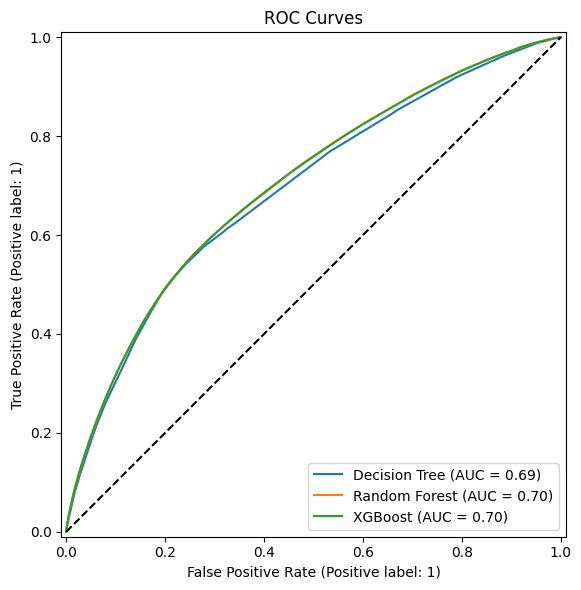

In [33]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [("Decision Tree", tree), ("Random Forest", rf_model), ("XGBoost", xgb_model)]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label="Random Chance")
ax.set_title("ROC Curves")
plt.tight_layout()
plt.show()

## Feature Engineering


In [34]:
filtered_df.head(10)

ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation,RainToday,RainTomorrow
str,date,f64,f64,i64,f64,f64,f64,i8,i8
"""US009052008""",2008-10-08,20.3,3.2,0,43.7333,-96.6333,482.0,0,0
"""US009052008""",2008-10-09,13.0,3.2,0,43.7333,-96.6333,482.0,0,0
"""US009052008""",2008-10-10,24.1,8.6,0,43.7333,-96.6333,482.0,0,1
"""US009052008""",2008-10-11,17.5,11.6,10,43.7333,-96.6333,482.0,1,1
"""US009052008""",2008-10-12,21.3,9.2,66,43.7333,-96.6333,482.0,1,1
"""US009052008""",2008-10-13,10.8,2.9,24,43.7333,-96.6333,482.0,1,1
"""US009052008""",2008-10-14,13.4,-0.6,4,43.7333,-96.6333,482.0,1,0
"""US009052008""",2008-10-15,11.7,1.7,0,43.7333,-96.6333,482.0,0,0
"""US009052008""",2008-10-16,13.0,-3.0,0,43.7333,-96.6333,482.0,0,1


In [35]:
filtered_df = filtered_df.with_columns([
    # Lag features for PRCP (most important)
    pl.col("PRCP").shift(1).over("ID").alias("PRCP_lag1"),
    pl.col("PRCP").shift(2).over("ID").alias("PRCP_lag2"),
    pl.col("PRCP").shift(3).over("ID").alias("PRCP_lag3"),
    pl.col("PRCP").shift(7).over("ID").alias("PRCP_lag7"),

    # Rolling precipitation features
    pl.col("PRCP").rolling_mean(7).over("ID").alias("PRCP_7day_avg"),
    pl.col("PRCP").rolling_sum(7).over("ID").alias("PRCP_7day_sum"),

    # Rain Streak
    (pl.col("RainToday").cast(pl.Int32).cum_sum().over("ID").over(
        ["ID", (pl.col("RainToday") == 0).cum_sum().over("ID")]
    )).alias("Rain Streak"),

    # Seasonality
    pl.col("DATE").dt.year().alias("Year"),
    pl.col("DATE").dt.month().alias("Month"),
    pl.col("DATE").dt.day().alias("Day"),

    # Temperature derived features
    (pl.col('TMAX') - pl.col('TMIN')).alias('Daily Temp Delta'),
    ((pl.col('TMAX') + pl.col('TMIN'))/2).alias('Daily Temp Average'),

    # Temperature lags
    (pl.col("TMAX") - pl.col("TMAX").shift(1).over("ID")).alias("TMAX_delta"),
    (pl.col("TMIN") - pl.col("TMIN").shift(1).over("ID")).alias("TMIN_delta"),

    # Precipitation lag (day over day)
    (pl.col('PRCP') - pl.col('PRCP').shift(1).over('ID')).alias('Day over Day Precipitation'),
])

In [36]:
model_df = filtered_df.select([
    "ID",
    "DATE",
    "TMAX", "TMIN", "PRCP",
    "PRCP_lag1", "PRCP_lag2", "PRCP_lag3", "PRCP_lag7",
    "PRCP_7day_avg", "PRCP_7day_sum",
    "Rain Streak",
    "Month",
    "Latitude", "Longitude",
    "TMAX_delta", "TMIN_delta",
    "RainTomorrow"
])

In [37]:
model_df.head(10)

ID,DATE,TMAX,TMIN,PRCP,PRCP_lag1,PRCP_lag2,PRCP_lag3,PRCP_lag7,PRCP_7day_avg,PRCP_7day_sum,Rain Streak,Month,Latitude,Longitude,TMAX_delta,TMIN_delta,RainTomorrow
str,date,f64,f64,i64,i64,i64,i64,i64,f64,i64,i32,i8,f64,f64,f64,f64,i8
"""US009052008""",2008-10-08,20.3,3.2,0,null,null,null,null,null,null,0,10,43.7333,-96.6333,null,null,0
"""US009052008""",2008-10-09,13.0,3.2,0,0,null,null,null,null,null,0,10,43.7333,-96.6333,-7.3,0.0,0
"""US009052008""",2008-10-10,24.1,8.6,0,0,0,null,null,null,null,0,10,43.7333,-96.6333,11.1,5.4,1
"""US009052008""",2008-10-11,17.5,11.6,10,0,0,0,null,null,null,1,10,43.7333,-96.6333,-6.6,3.0,1
"""US009052008""",2008-10-12,21.3,9.2,66,10,0,0,null,null,null,2,10,43.7333,-96.6333,3.8,-2.4,1
"""US009052008""",2008-10-13,10.8,2.9,24,66,10,0,null,null,null,3,10,43.7333,-96.6333,-10.5,-6.3,1
"""US009052008""",2008-10-14,13.4,-0.6,4,24,66,10,null,14.857143,104,4,10,43.7333,-96.6333,2.6,-3.5,0
"""US009052008""",2008-10-15,11.7,1.7,0,4,24,66,0,14.857143,104,0,10,43.7333,-96.6333,-1.7,2.3,0
"""US009052008""",2008-10-16,13.0,-3.0,0,0,4,24,0,14.857143,104,0,10,43.7333,-96.6333,1.3,-4.7,1


In [38]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(quantDDA(
    filtered_df
))

print("DATE min:", filtered_df["DATE"].min())
print("DATE max:", filtered_df["DATE"].max())
     

Sampled every 421th row → 100,230 rows used for stats


Feature,Total,Entries,Unique,Null,Outliers,Extreme,Mode,Mean,StdDev,Max,Min,Q1,Q2,Q3,Skew,Kurt,NonMissingPct
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Obs""",100230.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ID""",null,100230.0,5395.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""DATE""",null,100230.0,10590.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""TMAX""",null,99677.0,627.0,553.0,176.0,1857.0,27.8,17.16,11.8,128.7,-51.3,8.3,18.3,26.7,-0.3782,-0.3322,99.45
"""TMIN""",null,99657.0,625.0,573.0,727.0,1646.0,0.0,4.59,10.74,36.1,-69.4,-2.3,4.9,12.8,-0.3586,0.0153,99.43
"""PRCP""",null,99974.0,503.0,256.0,19853.0,990.0,0.0,24.75,78.05,2761.0,0.0,0.0,0.0,8.0,7.1788,95.3198,99.74
"""Latitude""",null,100230.0,5026.0,0.0,2445.0,1995.0,45.19,40.23,6.08,71.2869,19.2706,36.1639,40.4608,44.02,0.6299,2.6909,100.0
"""Longitude""",null,100230.0,5202.0,0.0,1050.0,1990.0,-107.06,-99.18,16.75,174.1,-170.2228,-111.4336,-97.7047,-85.8825,-0.4622,1.835,100.0
"""Elevation""",null,100230.0,2723.0,0.0,3135.0,1949.0,3.0,744.99,819.69,3541.8,-999.9,165.5,351.1,1205.2,1.3073,0.7277,100.0


DATE min: 1992-01-01
DATE max: 2021-12-30


# Re Running the Supervised Models


A comparison of models shows that XGBoost achieves the best overall performance, with an F1-score of approximately 0.55 and an AUC of approximately 0.74.

While the Decision Tree achieves higher accuracy (approx. 0.72), its very low recall (appprox. 0.24) indicates that it fails to detect a large portion of rain events.

In contrast, XGBoost significantly improves recall (approx. 0.68), resulting in a much higher F1-score. This demonstrates a better balance between precision and recall, which is critical for imbalanced classification problems.

The ROC curve for XGBoost shows a clear improvement, indicating stronger discriminative capability between rain and no-rain classes. This reflects the model’s improved ability to leverage the newly engineered features.

The confusion matrix further highlights this improvement. Compared to earlier results, XGBoost shows a substantial reduction in false negatives, which corresponds to the increase in recall. This means the model is significantly better at identifying actual rain events.

Therefore, XGBoost is selected as the best model due to its superior ability to identify the minority class while maintaining strong overall performance.

In [39]:
model_df_sample = model_df.drop_nulls().sample(fraction=0.10, seed=42)

pdf = model_df_sample.drop(["ID"]).to_pandas()
pdf["DATE"] = pd.to_datetime(pdf["DATE"])
pdf = pdf.sort_values("DATE")

train_end = pdf["DATE"].quantile(0.70)
val_end = pdf["DATE"].quantile(0.85)

train_df = pdf[pdf["DATE"] <= train_end]
val_df   = pdf[(pdf["DATE"] > train_end) & (pdf["DATE"] <= val_end)]
test_df  = pdf[pdf["DATE"] > val_end]

feature_cols = [c for c in pdf.columns if c not in ["DATE", "RainTomorrow"]]

X_train = train_df[feature_cols]
y_train = train_df["RainTomorrow"].astype(int)
X_val   = val_df[feature_cols]
y_val   = val_df["RainTomorrow"].astype(int)
X_test  = test_df[feature_cols]
y_test  = test_df["RainTomorrow"].astype(int)

print("Train size:", len(X_train))
print("Val size:  ", len(X_val))
print("Test size: ", len(X_test))
print("Features:  ", feature_cols)

Train size: 2879689
Val size:   616974
Test size:  616879
Features:   ['TMAX', 'TMIN', 'PRCP', 'PRCP_lag1', 'PRCP_lag2', 'PRCP_lag3', 'PRCP_lag7', 'PRCP_7day_avg', 'PRCP_7day_sum', 'Rain Streak', 'Month', 'Latitude', 'Longitude', 'TMAX_delta', 'TMIN_delta']


In [40]:
train_df = train_df.dropna(subset=feature_cols)
val_df   = val_df.dropna(subset=feature_cols)
test_df  = test_df.dropna(subset=feature_cols)

In [41]:
# RF stays at 500K sample
rf_sample = train_df.sample(n=500_000, random_state=42)
X_train_rf = rf_sample[feature_cols]
y_train_rf = rf_sample["RainTomorrow"].astype(int)

rf_model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf_model2.fit(X_train_rf, y_train_rf)

# XGBoost uses full training data
X_train_full = train_df[feature_cols]
y_train_full = train_df["RainTomorrow"].astype(int)

neg_count = (y_train_full == 0).sum()
pos_count = (y_train_full == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb_model2 = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=20,
    random_state=42
)

xgb_model2.fit(
    X_train_full, y_train_full,
    eval_set=[(X_val[feature_cols], y_val)],
    verbose=50
)

print("Best iteration:", xgb_model2.best_iteration)
print("Best val AUC:", xgb_model2.best_score)

[0]	validation_0-auc:0.69785
[50]	validation_0-auc:0.72883
[100]	validation_0-auc:0.73476
[150]	validation_0-auc:0.73715
[200]	validation_0-auc:0.73853
[250]	validation_0-auc:0.73937
[300]	validation_0-auc:0.73996
[350]	validation_0-auc:0.74047
[400]	validation_0-auc:0.74096
[450]	validation_0-auc:0.74120
[500]	validation_0-auc:0.74150
[550]	validation_0-auc:0.74175
[600]	validation_0-auc:0.74187
[650]	validation_0-auc:0.74204
[700]	validation_0-auc:0.74216
[750]	validation_0-auc:0.74223
[800]	validation_0-auc:0.74233
[850]	validation_0-auc:0.74246
[900]	validation_0-auc:0.74253
[950]	validation_0-auc:0.74257
[999]	validation_0-auc:0.74262
Best iteration: 999
Best val AUC: 0.7426173088284292


                            Accuracy  Precision    Recall        F1       AUC
XGBoost (engineered)        0.677947   0.470711  0.675703  0.554879  0.743936
Random Forest (engineered)  0.692110   0.484934  0.586032  0.530711  0.727134
Decision Tree (baseline)    0.723782   0.584912  0.241790  0.342145  0.690317

Decision Tree (baseline) Confusion Matrix:
[[402176  31445]
 [138948  44310]]

Random Forest (engineered) Confusion Matrix:
[[319553 114068]
 [ 75863 107395]]

XGBoost (engineered) Confusion Matrix:
[[294383 139238]
 [ 59430 123828]]


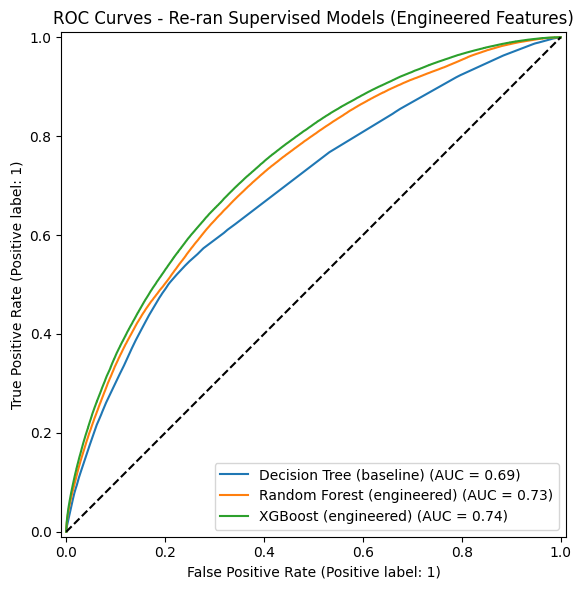

In [42]:
results2 = pd.DataFrame({
    "Decision Tree (baseline)": evaluate(tree, X_test[["TMAX", "TMIN", "PRCP"]], y_test),
    "Random Forest (engineered)": evaluate(rf_model2, X_test[feature_cols], y_test),
    "XGBoost (engineered)":       evaluate(xgb_model2, X_test[feature_cols], y_test)
}).T
print(results2.sort_values("AUC", ascending=False))

# Confusion matrices for re-ran models
for name, model, cols in [
    ("Decision Tree (baseline)", tree, ["TMAX", "TMIN", "PRCP"]),
    ("Random Forest (engineered)", rf_model2, feature_cols),
    ("XGBoost (engineered)", xgb_model2, feature_cols)
]:
    pred = model.predict(X_test[cols])
    print(f"\n{name} Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

# ROC curves for re-ran models
fig, ax = plt.subplots(figsize=(8, 6))

for name, model, cols in [
    ("Decision Tree (baseline)", tree, ["TMAX", "TMIN", "PRCP"]),
    ("Random Forest (engineered)", rf_model2, feature_cols),
    ("XGBoost (engineered)", xgb_model2, feature_cols)
]:
    RocCurveDisplay.from_estimator(model, X_test[cols], y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label="Random Chance")
ax.set_title("ROC Curves - Re-ran Supervised Models (Engineered Features)")
plt.tight_layout()
plt.show()

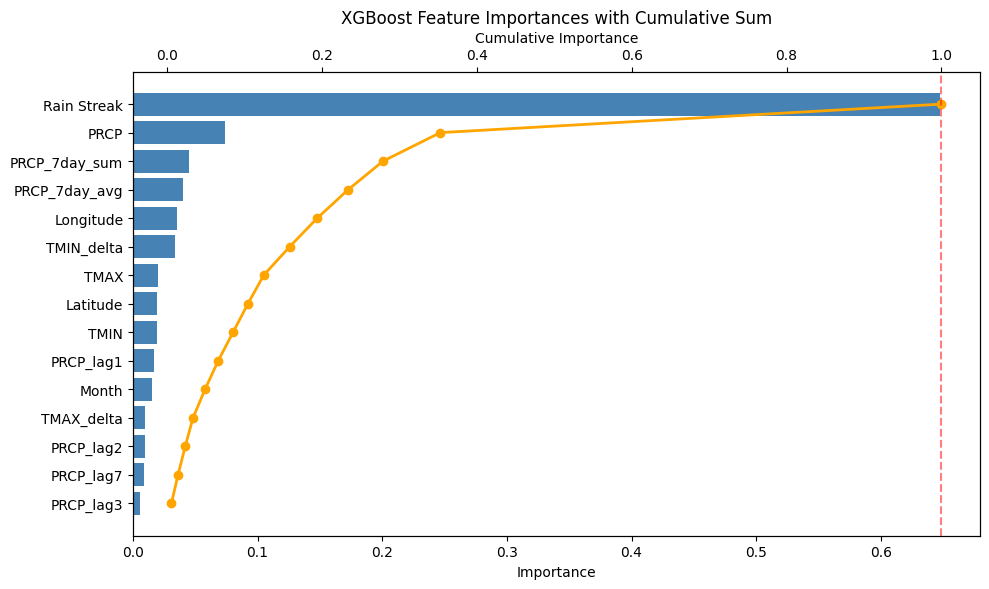

,Feature,Importance,Cumulative Importance
9,Rain Streak,0.647217,1.000000
2,PRCP,0.073912,0.352783
8,PRCP_7day_sum,0.045025,0.278870
7,PRCP_7day_avg,0.039997,0.233845
12,Longitude,0.035501,0.193848
14,TMIN_delta,0.033569,0.158347
0,TMAX,0.020362,0.124779
11,Latitude,0.019194,0.104417
1,TMIN,0.019181,0.085223
3,PRCP_lag1,0.016968,0.066042


In [43]:
importance_df2 = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model2.feature_importances_
}).sort_values("Importance", ascending=True)  # ascending for barh readability

importance_df2["Cumulative Importance"] = importance_df2["Importance"].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.barh(importance_df2["Feature"], importance_df2["Importance"], color="steelblue")
ax1.set_xlabel("Importance")
ax1.set_title("XGBoost Feature Importances with Cumulative Sum")

ax2 = ax1.twiny()
ax2.plot(importance_df2["Cumulative Importance"], importance_df2["Feature"], 
         color="orange", marker="o", linewidth=2)
ax2.set_xlabel("Cumulative Importance")
ax2.axvline(x=1.0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

importance_df2.sort_values("Importance", ascending=False)

## Partial Dependency Plots

The partial dependency plots are used to show which features matter and in what ways.

- For PRCP and PRCP-lag1, we see that as precipitation increases the probability rises, meaning that immediate-recent rainfall is a strong indicator of upcoming rain.
- The Rain Streak is the most important feature, saying that for consecutive rainy days, we are more likely to see the rain continue.
- Month captures the importance of seasonal trends and reoccuring patterns in months year after year.

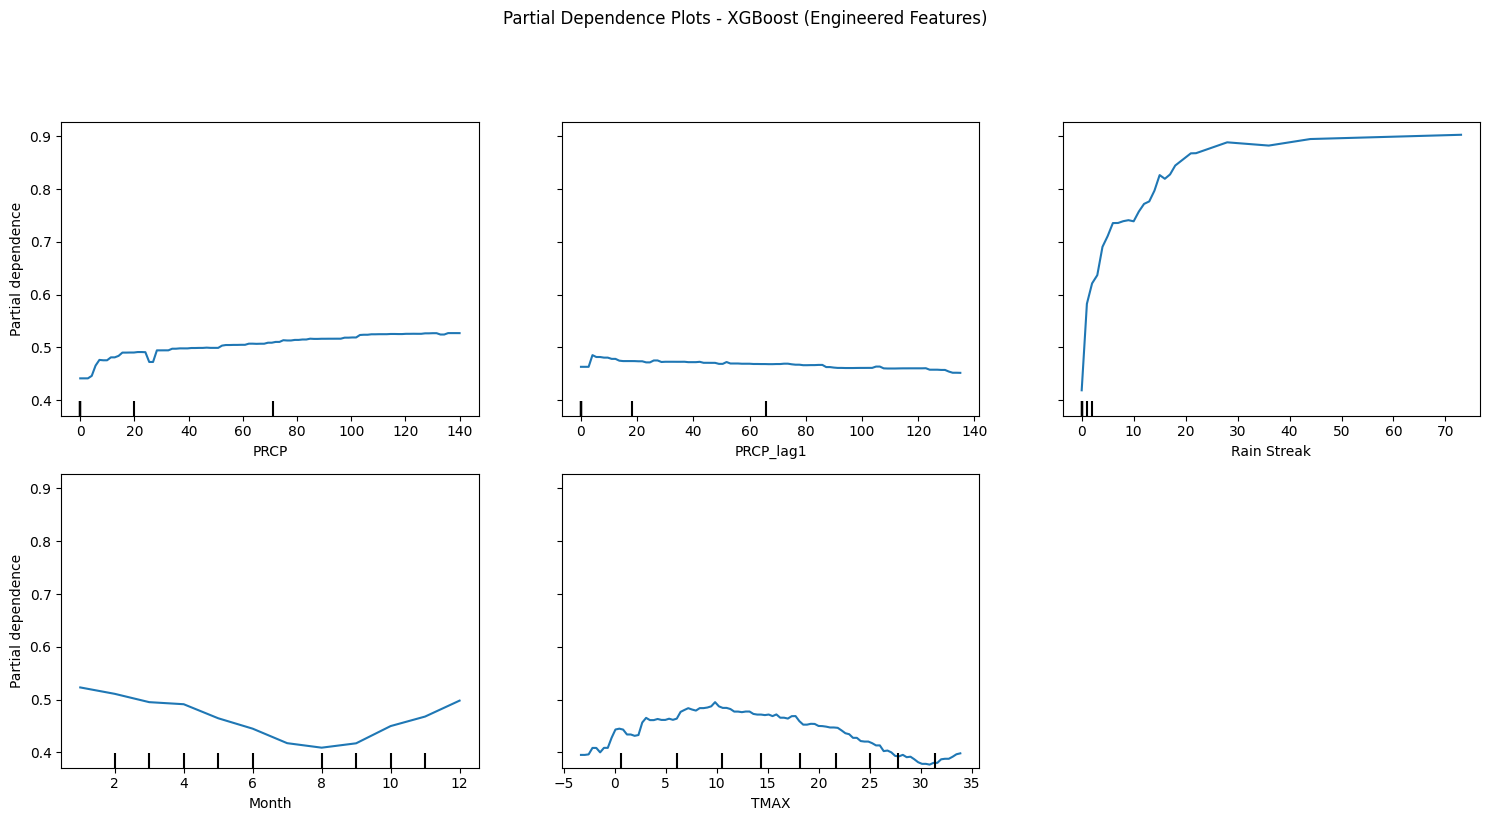

In [44]:
from sklearn.inspection import PartialDependenceDisplay

top_features = ["PRCP", "PRCP_lag1", "Rain Streak", "Month", "TMAX"]
feature_indices = [feature_cols.index(f) for f in top_features]

fig, ax = plt.subplots(figsize=(15, 8))  
PartialDependenceDisplay.from_estimator(
    xgb_model2,
    X_train_full.astype(float).sample(10_000, random_state=42),
    features=feature_indices,
    feature_names=feature_cols,
    ax=ax,
    n_jobs=1,
)
plt.suptitle("Partial Dependence Plots - XGBoost (Engineered Features)", y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

## PCA

To better understand the structure of the dataset, Principal Component Analysis (PCA) was applied after feature engineering.

PCA reduces the dimensionality of the dataset by transforming the original features into a smaller set of components that capture the most variance in the data. The first two principal components (PC1 and PC2) were used for visualization purposes.

It is important to note that these components are linear combinations of the original features and do not directly correspond to specific variables.

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [46]:
# Prepare the unsupervised dataset
# Use engineered numeric features only
# Exclude identifiers, date, and target columns


# Sample before PCA/KMeans — these are scale-sensitive
filtered_sample = filtered_df.sample(fraction=0.05, seed=42) #added filtered_sample to take subset of data

unsup_df = filtered_sample.select([
    "TMAX",
    "TMIN",
    "PRCP",
    "Latitude",
    "Longitude",
    "Elevation",
    "Daily Temp Delta",
    "Daily Temp Average",
    "TMAX_delta",
    "TMIN_delta",
    "Day over Day Precipitation",
    "Rain Streak",
    "Year",
    "Month",
    "Day"
])

# Drop rows with nulls to make PCA/KMeans work cleanly
unsup_df = unsup_df.drop_nulls()

# Convert to pandas
unsup_pd = unsup_df.to_pandas()

print("Shape of unsupervised dataset:", unsup_pd.shape)
unsup_pd.head()

Shape of unsupervised dataset: (2079788, 15)


,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation,Daily Temp Delta,Daily Temp Average,TMAX_delta,TMIN_delta,Day over Day Precipitation,Rain Streak,Year,Month,Day
0,23.9,2.8,0,36.6169,-87.4117,167.6,21.1,13.35,4.5,-0.5,0,0,2020,10,6
1,2.8,-15.6,0,42.4244,-103.7347,1423.4,18.4,-6.40,-2.8,-10.0,0,0,1996,12,15
2,-0.5,-11.0,38,44.5447,-110.4219,2372.0,10.5,-5.75,-2.7,-6.1,18,3,2018,3,24
3,14.8,-0.6,0,44.7300,-109.9100,2865.1,15.4,7.10,7.0,4.7,0,0,2009,9,22
4,3.9,-2.7,0,43.4500,-122.1400,1709.9,6.6,0.60,3.2,-0.5,0,0,2020,1,3


In [47]:
# Standardize the data
# PCA and KMeans are scale-sensitive


scaler = StandardScaler()
X_scaled = scaler.fit_transform(unsup_pd)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2079788, 15)


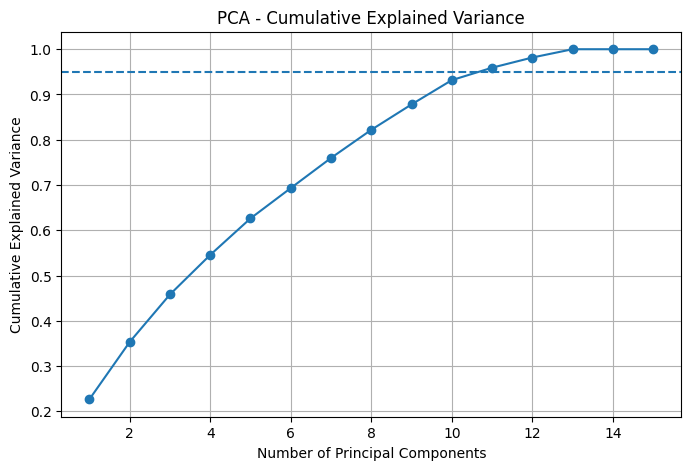

Number of components needed to explain at least 95% variance: 11


In [48]:
# PCA - find how many components explain 95% variance


pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components needed to explain at least 95% variance:", n_components_95)

In [49]:
# Apply PCA with selected number of components

pca = PCA(n_components=n_components_95)
X_reduced = pca.fit_transform(X_scaled)

print("Reduced data shape:", X_reduced.shape)

Reduced data shape: (2079788, 11)


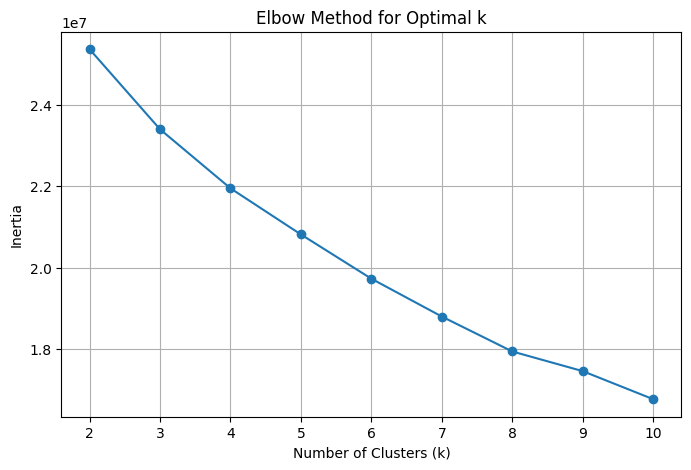

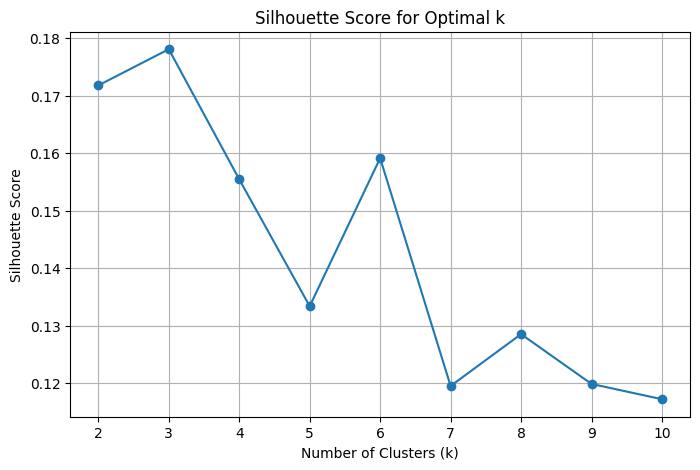

Optimal number of clusters based on silhouette score: 3


In [50]:
# Determine optimal number of clusters
# Use both Elbow Method and Silhouette Score


k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_reduced)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_reduced, cluster_labels, sample_size=10_000, random_state=42))
    
# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(silhouette_scores)]
print("Optimal number of clusters based on silhouette score:", optimal_k)

In [51]:
# Fit final KMeans model


kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_reduced)

unsup_pd["Cluster"] = clusters

print("Cluster counts:")
print(unsup_pd["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0      98989
1    1092035
2     888764
Name: count, dtype: int64


In [52]:
# Evaluate cluster quality


final_silhouette = silhouette_score(X_reduced, clusters, sample_size=10_000, random_state=42)

print("Final silhouette score:", final_silhouette)

Final silhouette score: 0.1781019581728302


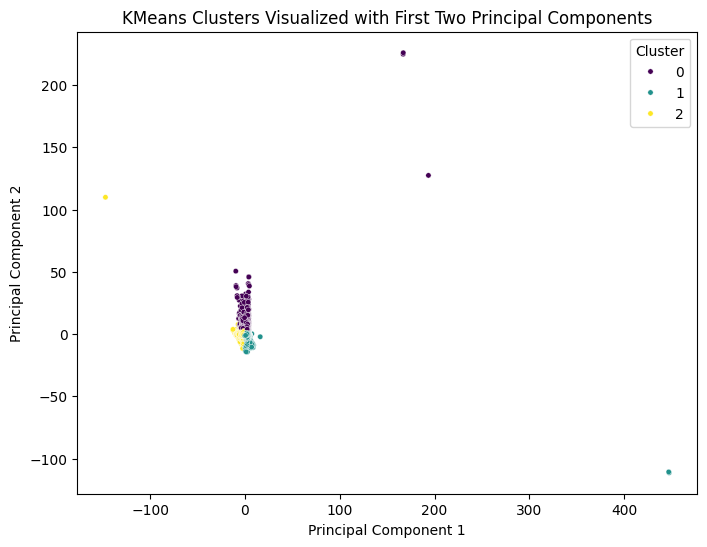

In [53]:
# Visualize clusters in 2D using PCA
# This is only for plotting


pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "Cluster": clusters
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="viridis", s=15)
plt.title("KMeans Clusters Visualized with First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [54]:
# Profile the clusters
# This helps interpret what each cluster represents


cluster_profile = unsup_pd.groupby("Cluster").mean(numeric_only=True)
print("Cluster profile (mean values):")
display(cluster_profile)

Cluster profile (mean values):


,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation,Daily Temp Delta,Daily Temp Average,TMAX_delta,TMIN_delta,Day over Day Precipitation,Rain Streak,Year,Month,Day
Cluster,,,,,,,,,,,,,,,
0,17.830411,9.527602,289.60040,39.478495,-94.169822,418.971348,8.302809,13.679007,-1.390907,0.317546,236.486600,2.975381,2006.881169,6.637445,15.944357
1,25.791291,11.608711,9.10337,37.963426,-95.643956,508.789555,14.182581,18.700001,0.658222,0.339520,-13.689795,0.379268,2006.784943,7.040264,15.778312
2,6.508079,-4.533977,14.24062,43.107324,-104.071782,1070.887685,11.042056,0.987051,-0.639197,-0.430584,-9.402377,0.710192,2006.703659,5.881974,15.650866


In [55]:
# variance explained by the 2D visualization


pca_2d_check = PCA(n_components=2)
pca_2d_check.fit(X_scaled)

print("Explained variance by PC1 and PC2:", pca_2d_check.explained_variance_ratio_)
print("Total explained variance by first 2 PCs:", pca_2d_check.explained_variance_ratio_.sum())

Explained variance by PC1 and PC2: [0.22669521 0.12656289]
Total explained variance by first 2 PCs: 0.35325809624961146


## Cluster Visualization and Interpretation

The clustering results show significant overlap between clusters in the PCA space, indicating that the separation between groups is not strong.

The silhouette score for the clustering is approximately 0.18, which indicates weak separation between clusters. This low value suggests that many data points are close to the boundaries between clusters, and that the clusters are not well-defined.

The isolated points are assigned to clusters, but some appear distant due to dimensionality reduction effects. This result is consistent with the nature of weather data, where conditions change gradually over time rather than forming distinct and isolated groups.

To interpret the clusters, we analyze the average feature values within each cluster. This allows us to identify general patterns such as high precipitation conditions, warm and dry weather, or colder environments.

These clusters reflect tendencies in the data rather than strictly defined categories.

## Final Analysis

### Supervised Learning Insights

The supervised models demonstrate that rainfall prediction can be effectively addressed using XGBoost. It indicated a strong ability to distinguish between rain and no-rain events.

The ROC curve further supports this, as the model maintains a good balance between true positive rate and false positive rate across thresholds. The relatively high AUC confirms that the model has strong discriminative power.

This is also evident in the confusion matrix, where XGBoost significantly reduces false negatives, improving recall and resulting in a more balanced and reliable model.

The results also highlight that for imbalanced datasets, metrics such as F1-score and AUC are more meaningful than accuracy.

### Unsupervised Learning Insights

The unsupervised analysis using PCA and KMeans clustering reveals that weather patterns do not form clearly distinct groups.

The PCA visualization shows overlapping clusters, and this is quantitatively supported by the low silhouette score, indicating weak cluster separation. Many data points lie near cluster boundaries, suggesting that the clusters are not well-defined.

This implies that weather conditions vary continuously rather than forming discrete categories. While clustering captures general tendencies in the data, it does not identify strongly separable weather regimes.